## **Task 3**

In [1]:
!py -m pip install ultralytics


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ALEJANDRA\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import csv
import shutil
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

In [3]:
DATASET_ROOT = Path(r"C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Año\Semestre 1\Vision\LAB8-VPC\dataset")
 
SPLITS = ["train", "val", "test"]
 
CLASS_NAMES = ["Bottle", "Food", "Drink"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

In [4]:
def convert_annotations(split: str):
    ann_path = DATASET_ROOT / split / "labels_csv" / "annotations.csv"
    img_dir   = DATASET_ROOT / split / "images"
    out_dir   = DATASET_ROOT / split / "labels_yolo"
    out_dir.mkdir(exist_ok=True)
 
    # Leer CSV
    rows = []
    with open(ann_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
 
    # Agrupar por imagen
    by_image = {}
    for r in rows:
        iid = r["ImageID"]
        if iid not in by_image:
            by_image[iid] = []
        by_image[iid].append(r)
 
    converted = 0
    skipped   = 0
 
    for image_id, anns in by_image.items():
        # Buscar el archivo de imagen
        img_file = None
        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = img_dir / f"{image_id}{ext}"
            if candidate.exists():
                img_file = candidate
                break
 
        if img_file is None:
            skipped += 1
            continue
 
        lines = []
        for a in anns:
            cls = a["ClassName"]
            if cls not in CLASS_TO_IDX:
                continue
 
            xmin = float(a["XMin"])
            xmax = float(a["XMax"])
            ymin = float(a["YMin"])
            ymax = float(a["YMax"])
 
            # Convertir a formato YOLO (cx, cy, w, h) 
            cx = (xmin + xmax) / 2
            cy = (ymin + ymax) / 2
            w  = xmax - xmin
            h  = ymax - ymin
 
            class_id = CLASS_TO_IDX[cls]
            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
 
        if lines:
            out_file = out_dir / f"{image_id}.txt"
            out_file.write_text("\n".join(lines))
            converted += 1
 
    print(f"[{split}] Convertidas: {converted} | Sin imagen: {skipped}")
    return converted
 
for split in SPLITS:
    convert_annotations(split)

[train] Convertidas: 609 | Sin imagen: 91
[val] Convertidas: 111 | Sin imagen: 14
[test] Convertidas: 106 | Sin imagen: 19


In [5]:
yaml_data = {
    "path": str(DATASET_ROOT),
    "train": "train/images",
    "val":   "val/images",
    "test":  "test/images",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
 
yaml_path = DATASET_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_data, f, default_flow_style=False, allow_unicode=True)
 
print(f"data.yaml guardado en: {yaml_path}")
print(yaml.dump(yaml_data, default_flow_style=False))

data.yaml guardado en: C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Año\Semestre 1\Vision\LAB8-VPC\dataset\data.yaml
names:
- Bottle
- Food
- Drink
nc: 3
path: "C:\\Users\\ALEJANDRA\\OneDrive - UVG\\Escritorio\\Quinto A\xF1o\\Semestre 1\\\
  Vision\\LAB8-VPC\\dataset"
test: test/images
train: train/images
val: val/images



Distribución de clases por split:

  train: {'Bottle': 1630, 'Food': 941, 'Drink': 650}  → total bboxes: 3221
  val: {'Bottle': 16, 'Food': 146, 'Drink': 39}  → total bboxes: 201
  test: {'Bottle': 21, 'Food': 147, 'Drink': 35}  → total bboxes: 203


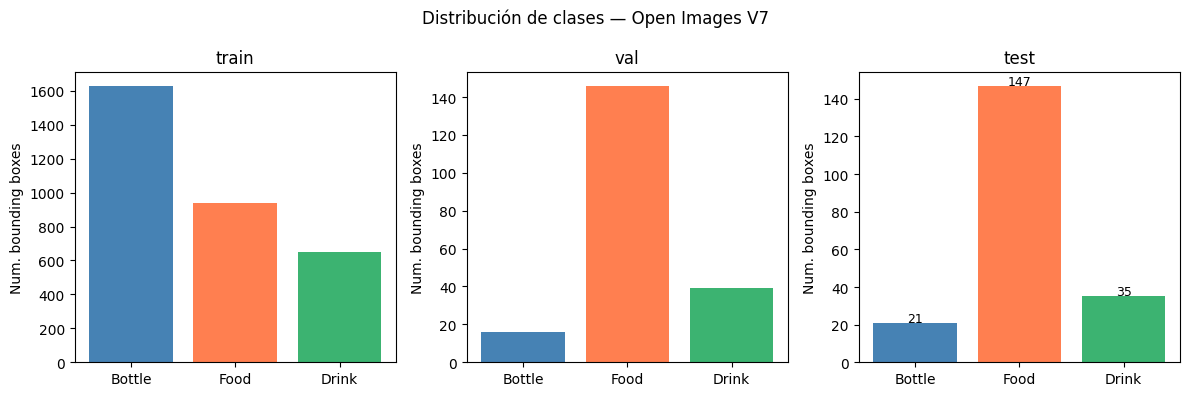

In [7]:
def count_classes(split: str):
    ann_path = DATASET_ROOT / split / "labels_csv" / "annotations.csv"
    counts = {c: 0 for c in CLASS_NAMES}
    with open(ann_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            cls = row["ClassName"]
            if cls in counts:
                counts[cls] += 1
    return counts
 
print("Distribución de clases por split:\n")
all_counts = {}
for split in SPLITS:
    counts = count_classes(split)
    all_counts[split] = counts
    total = sum(counts.values())
    print(f"  {split}: {counts}  → total bboxes: {total}")
 
# Gráfico de distribución
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, split in zip(axes, SPLITS):
    counts = all_counts[split]
    ax.bar(counts.keys(), counts.values(), color=["steelblue", "coral", "mediumseagreen"])
    ax.set_title(split)
    ax.set_ylabel("Num. bounding boxes")
for v, rect in zip(counts.values(), ax.patches):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.5,
            str(v), ha="center", fontsize=9)
plt.suptitle("Distribución de clases — Open Images V7")
plt.tight_layout()
plt.savefig(str(DATASET_ROOT / "class_distribution.png"), dpi=120)
plt.show()

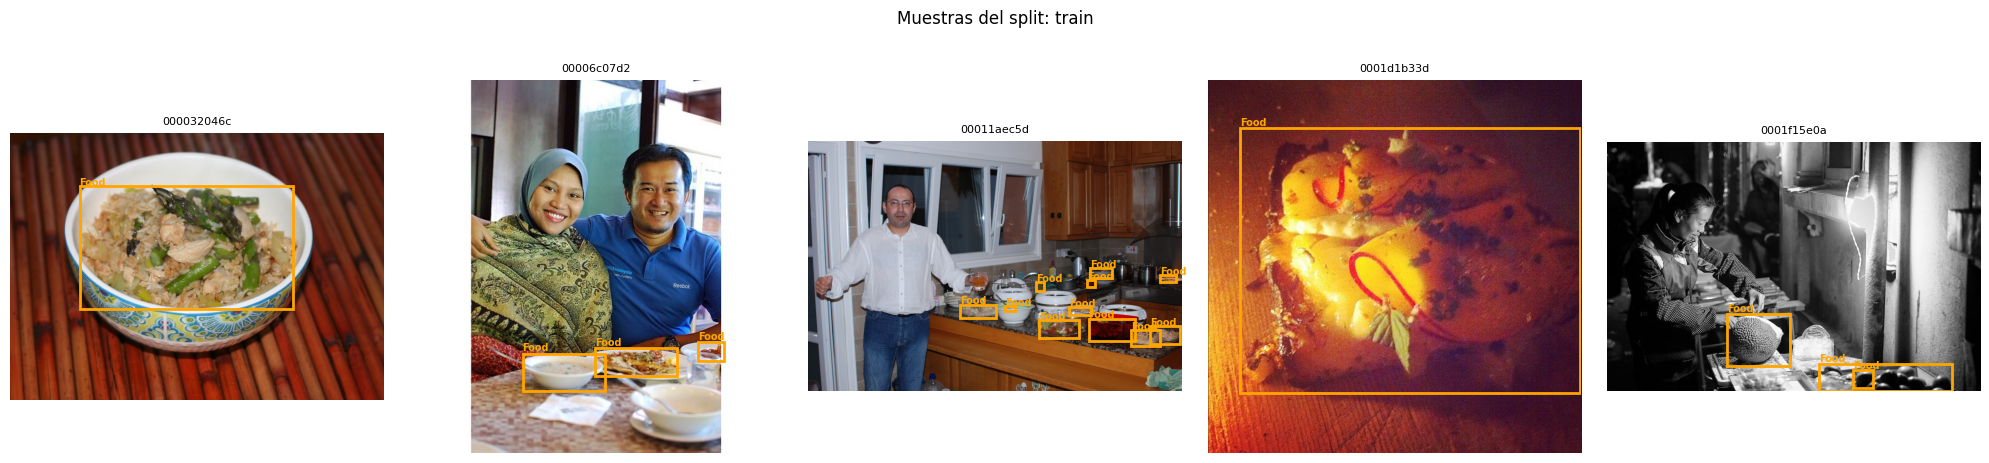

In [8]:
def load_annotations_for_image(image_id: str, split: str):
    ann_path = DATASET_ROOT / split / "labels_csv" / "annotations.csv"
    boxes = []
    with open(ann_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            if row["ImageID"] == image_id:
                boxes.append(row)
    return boxes
 
def visualize_samples(split="train", n=5):
    img_dir = DATASET_ROOT / split / "images"
    images  = list(img_dir.iterdir())[:n]
 
    COLORS = {"Bottle": "red", "Food": "orange", "Drink": "cyan"}
 
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    for ax, img_path in zip(axes, images):
        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        image_id = img_path.stem
 
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(image_id[:10], fontsize=8)
 
        boxes = load_annotations_for_image(image_id, split)
        for b in boxes:
            cls  = b["ClassName"]
            xmin = float(b["XMin"]) * W
            xmax = float(b["XMax"]) * W
            ymin = float(b["YMin"]) * H
            ymax = float(b["YMax"]) * H
            color = COLORS.get(cls, "white")
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(xmin, ymin - 4, cls, color=color, fontsize=7, fontweight="bold")
 
    plt.suptitle(f"Muestras del split: {split}")
    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / f"samples_{split}.png"), dpi=120)
    plt.show()
 
visualize_samples("train", n=5)

In [9]:
def sync_labels(split: str):
    """
    Copia los archivos .txt de labels_yolo a labels,
    que es donde Ultralytics los busca automáticamente.
    """
    src = DATASET_ROOT / split / "labels_yolo"
    dst = DATASET_ROOT / split / "labels"
    dst.mkdir(exist_ok=True)
    for txt in src.glob("*.txt"):
        shutil.copy2(txt, dst / txt.name)
    print(f"[{split}] Copiados {len(list(src.glob('*.txt')))} archivos a labels/")
 
for split in ["train", "val", "test"]:
    sync_labels(split)

[train] Copiados 609 archivos a labels/
[val] Copiados 111 archivos a labels/
[test] Copiados 106 archivos a labels/


In [10]:
SHARED_KWARGS = dict(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=8,
    lr0=0.001,
    lrf=0.01,
    optimizer="AdamW",
    patience=5,       # early stopping
    freeze=10,        # backbone congelado
    val=True,
    plots=True,
    exist_ok=True,
)
 

In [11]:
model_n = YOLO("yolov8n.pt")   # pesos preentrenados en COCO
 
results_n = model_n.train(
    name="visorshelf_yolov8n",
    **SHARED_KWARGS,
)
 
# Guardar ruta del mejor modelo
best_n = Path(model_n.trainer.best)
print(f"Mejor modelo YOLOv8n: {best_n}")

Ultralytics 8.4.39  Python-3.10.20 torch-2.12.0.dev20260312+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Ao\Semestre 1\Vision\LAB8-VPC\dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [12]:
import gc
import torch

# Después de terminar YOLOv8n
del model_n
gc.collect()
torch.cuda.empty_cache()

In [13]:
model_s = YOLO("yolov8s.pt")
 
results_s = model_s.train(
    name="visorshelf_yolov8s",
    **SHARED_KWARGS,
)
 
best_s = Path(model_s.trainer.best)
print(f"Mejor modelo YOLOv8s: {best_s}")

Ultralytics 8.4.39  Python-3.10.20 torch-2.12.0.dev20260312+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Ao\Semestre 1\Vision\LAB8-VPC\dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [14]:
def print_train_summary(results, name: str):
    metrics = results.results_dict
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
 
print_train_summary(results_n, "YOLOv8n")
print_train_summary(results_s, "YOLOv8s")


--- YOLOv8n ---
  metrics/precision(B): 0.5828
  metrics/recall(B): 0.2672
  metrics/mAP50(B): 0.2614
  metrics/mAP50-95(B): 0.1789
  fitness: 0.1789

--- YOLOv8s ---
  metrics/precision(B): 0.5816
  metrics/recall(B): 0.3402
  metrics/mAP50(B): 0.2605
  metrics/mAP50-95(B): 0.1508
  fitness: 0.1508


In [15]:
BEST_N = Path("runs/detect/visorshelf_yolov8n/weights/best.pt")
BEST_S = Path("runs/detect/visorshelf_yolov8s/weights/best.pt")

In [16]:
def evaluate_model(weights_path: Path, name: str, data_yaml: Path):
    model = YOLO(str(weights_path))
    metrics = model.val(
        data=str(data_yaml),
        split="test",
        imgsz=640,
        batch=16,
        verbose=False,
    )
    print(f"\n=== {name} — métricas en test ===")
    print(f"  mAP@0.5        : {metrics.box.map50:.4f}")
    print(f"  mAP@0.5:0.95   : {metrics.box.map:.4f}")
    print(f"  Precisión      : {metrics.box.mp:.4f}")
    print(f"  Recall         : {metrics.box.mr:.4f}")
    return metrics
 
yaml_path = DATASET_ROOT / "data.yaml"
 
metrics_n = evaluate_model(BEST_N, "YOLOv8n", yaml_path)
metrics_s = evaluate_model(BEST_S, "YOLOv8s", yaml_path)

Ultralytics 8.4.39  Python-3.10.20 torch-2.12.0.dev20260312+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 528.6412.2 MB/s, size: 710.1 KB)
val: Scanning C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Año\Semestre 1\Vision\LAB8-VPC\dataset\test\labels... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 1.4Kit/s 0.1s
val: New cache created: C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Ao\Semestre 1\Vision\LAB8-VPC\dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1it/s 6.2s0.4s7
                   all        106        179      0.535      0.355      0.295      0.208
Speed: 7.8ms preprocess, 6.2ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\ALEJANDRA\OneDrive - UVG\Escritorio\Quinto Ao\Semestre 1\Vision

In [18]:
import time

def measure_fps(weights_path: Path, name: str, n_images: int = 50):
    model = YOLO(str(weights_path))
    test_imgs = list((DATASET_ROOT / "test" / "images").iterdir())[:n_images]
 
    # Warm-up
    _ = model.predict(str(test_imgs[0]), verbose=False)
 
    start = time.perf_counter()
    for img_path in test_imgs:
        _ = model.predict(str(img_path), imgsz=640, verbose=False)
    elapsed = time.perf_counter() - start
 
    fps = n_images / elapsed
    print(f"{name}: {fps:.2f} FPS ({elapsed:.2f} s para {n_images} imágenes)")
    return fps
 
fps_n = measure_fps(BEST_N, "YOLOv8n")
fps_s = measure_fps(BEST_S, "YOLOv8s")

YOLOv8n: 20.00 FPS (2.50 s para 50 imágenes)
YOLOv8s: 19.95 FPS (2.51 s para 50 imágenes)


In [19]:
def model_size_mb(weights_path: Path):
    size_mb = weights_path.stat().st_size / (1024 ** 2)
    return round(size_mb, 2)
 
size_n = model_size_mb(BEST_N)
size_s = model_size_mb(BEST_S)
print(f"YOLOv8n: {size_n} MB")
print(f"YOLOv8s: {size_s} MB")

YOLOv8n: 5.96 MB
YOLOv8s: 21.48 MB


In [20]:
print("\n{'='*55}")
print(f"{'Métrica':<25} {'YOLOv8n':>12} {'YOLOv8s':>12}")
print(f"{'='*55}")
rows = [
    ("mAP@0.5",        f"{metrics_n.box.map50:.4f}",  f"{metrics_s.box.map50:.4f}"),
    ("mAP@0.5:0.95",   f"{metrics_n.box.map:.4f}",    f"{metrics_s.box.map:.4f}"),
    ("Precisión",      f"{metrics_n.box.mp:.4f}",      f"{metrics_s.box.mp:.4f}"),
    ("Recall",         f"{metrics_n.box.mr:.4f}",      f"{metrics_s.box.mr:.4f}"),
    ("FPS",            f"{fps_n:.2f}",                 f"{fps_s:.2f}"),
    ("Tamaño (MB)",    f"{size_n}",                    f"{size_s}"),
]
for label, vn, vs in rows:
    print(f"{label:<25} {vn:>12} {vs:>12}")
print(f"{'='*55}")


{'='*55}
Métrica                        YOLOv8n      YOLOv8s
mAP@0.5                         0.2950       0.2253
mAP@0.5:0.95                    0.2075       0.1470
Precisión                       0.5349       0.3972
Recall                          0.3545       0.2892
FPS                              20.00        19.95
Tamaño (MB)                       5.96        21.48


Mejor modelo: YOLOv8n


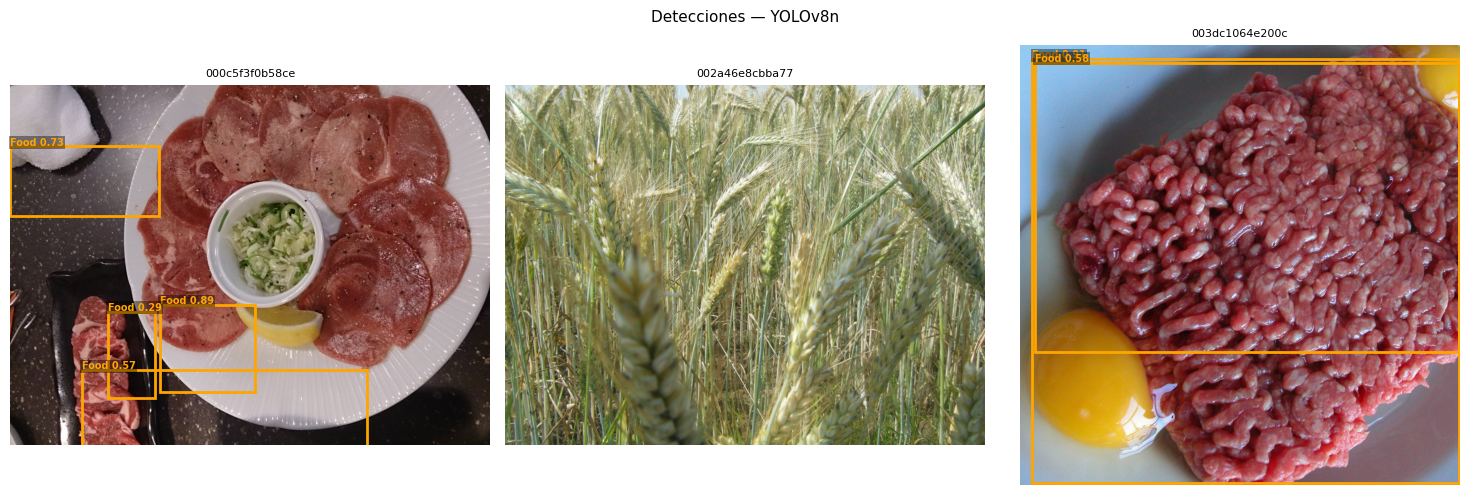

In [21]:
best_model_path = BEST_S if metrics_s.box.map50 > metrics_n.box.map50 else BEST_N
best_label      = "YOLOv8s" if metrics_s.box.map50 > metrics_n.box.map50 else "YOLOv8n"
print(f"Mejor modelo: {best_label}")
 
best_model = YOLO(str(best_model_path))
CLASS_NAMES = ["Bottle", "Food", "Drink"]
COLORS = {"Bottle": "red", "Food": "orange", "Drink": "cyan"}
 
test_images = list((DATASET_ROOT / "test" / "images").iterdir())[:3]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for ax, img_path in zip(axes, test_images):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
 
    results = best_model.predict(str(img_path), imgsz=640, verbose=False)[0]
 
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:14], fontsize=8)
 
    for box in results.boxes:
        cls_id = int(box.cls)
        conf   = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
        color = COLORS.get(cls_name, "white")
 
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{cls_name} {conf:.2f}",
                color=color, fontsize=7, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))
 
plt.suptitle(f"Detecciones — {best_label}", fontsize=11)
plt.tight_layout()
plt.savefig(str(DATASET_ROOT / f"detections_{best_label}.png"), dpi=120)
plt.show()

In [22]:
map_n = metrics_n.box.map50
map_s = metrics_s.box.map50
 
ratio_n = size_n / map_n if map_n > 0 else float("inf")
ratio_s = size_s / map_s if map_s > 0 else float("inf")
 
print(f"YOLOv8n — MB/mAP@0.5: {ratio_n:.3f}")
print(f"YOLOv8s — MB/mAP@0.5: {ratio_s:.3f}")
 

YOLOv8n — MB/mAP@0.5: 20.201
YOLOv8s — MB/mAP@0.5: 95.356
